1.Extract the ZIP file



In [2]:
import zipfile

zip_path = "/content/fer2013.zip"
extract_path = "/content/fer2013"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

2.Data Understanding


In [19]:
import tensorflow
from tensorflow import keras
import os
import matplotlib.pyplot as plt
from PIL import Image

In [20]:
dataset_path = "/content/fer2013"

print(os.listdir(dataset_path))

['train', 'test']


In [21]:
train_path = os.path.join(dataset_path, "train")

classes = os.listdir(train_path)
print(classes)

['fear', 'disgust', 'surprise', 'neutral', 'angry', 'sad', 'happy']


In [22]:
train_path = os.path.join(dataset_path, "train")

for emotion in classes:
    emotion_path = os.path.join(train_path, emotion)
    print(f"{emotion}: {len(os.listdir(emotion_path))} images")

fear: 4097 images
disgust: 436 images
surprise: 3171 images
neutral: 4965 images
angry: 3995 images
sad: 4830 images
happy: 7215 images


In [23]:
test_path = os.path.join(dataset_path, "test")

for emotion in classes:
    emotion_path = os.path.join(test_path, emotion)
    print(f"{emotion}: {len(os.listdir(emotion_path))} images")

fear: 1024 images
disgust: 111 images
surprise: 831 images
neutral: 1233 images
angry: 958 images
sad: 1247 images
happy: 1774 images


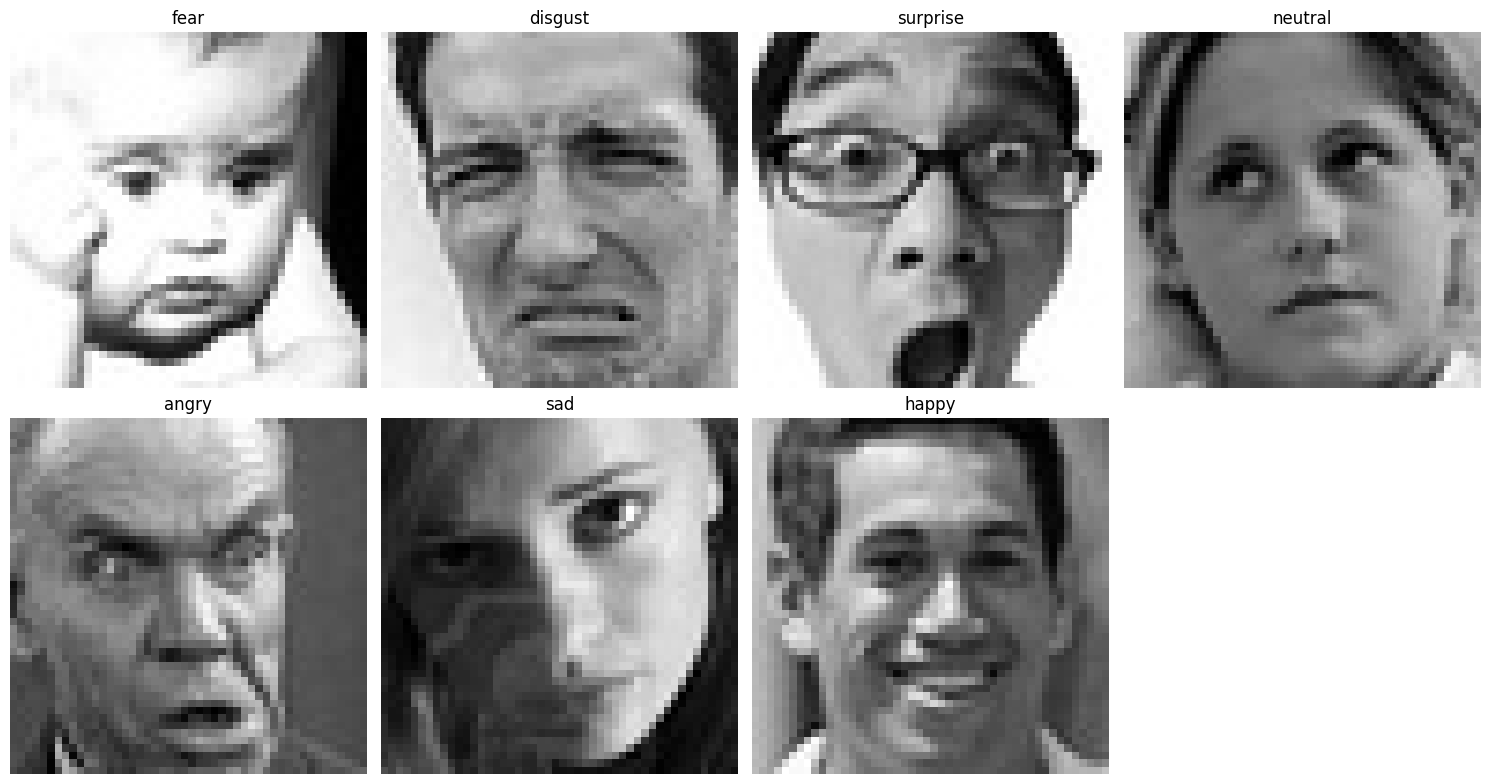

In [24]:
plt.figure(figsize=(15, 8))

for i, emotion in enumerate(classes):
    emotion_path = os.path.join(train_path, emotion)
    image_name = os.listdir(emotion_path)[0]
    image_path = os.path.join(emotion_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
sample_image_path = os.path.join(
    train_path,
    classes[0],
    os.listdir(os.path.join(train_path, classes[0]))[0]
)

image = Image.open(sample_image_path)

print("Image Size:", image.size)
print("Image Mode:", image.mode)

Image Size: (48, 48)
Image Mode: L


3.EDA

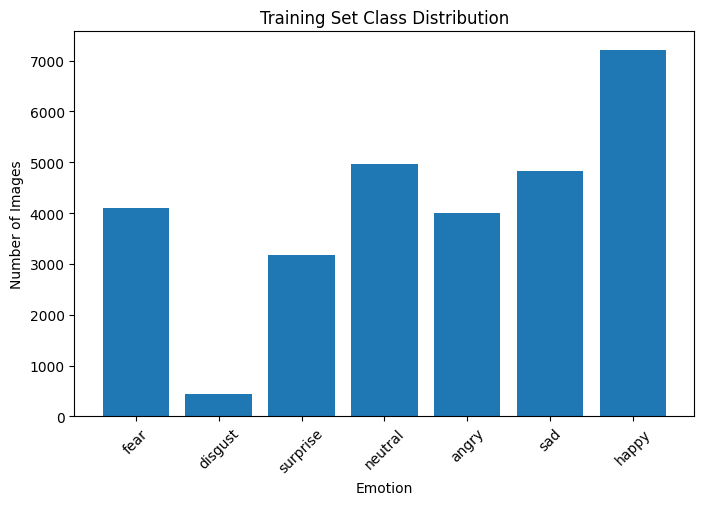

In [26]:
train_counts = []

for emotion in classes:
    emotion_path = os.path.join(train_path, emotion)
    train_counts.append(len(os.listdir(emotion_path)))

plt.figure(figsize=(8,5))
plt.bar(classes, train_counts)
plt.title("Training Set Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

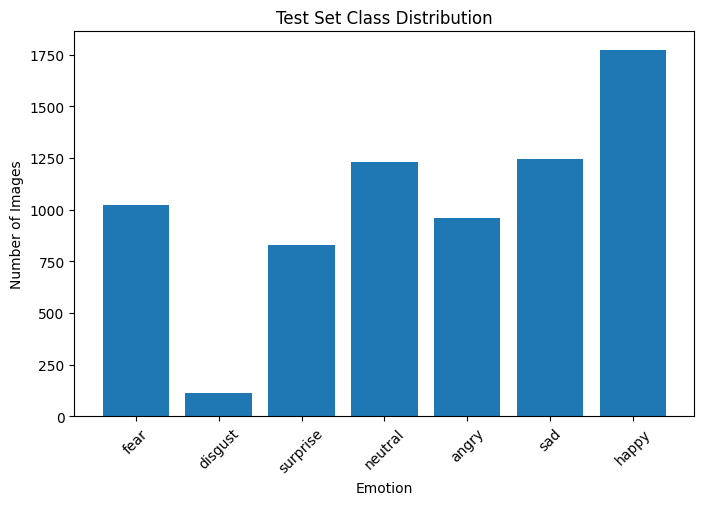

In [27]:
test_counts = []

for emotion in classes:
    emotion_path = os.path.join(test_path, emotion)
    test_counts.append(len(os.listdir(emotion_path)))

plt.figure(figsize=(8,5))
plt.bar(classes, test_counts)
plt.title("Test Set Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

4.Data Pereprocessing


In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [29]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 22968 images belonging to 7 classes.


In [30]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

Found 5741 images belonging to 7 classes.


In [31]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [32]:
print("Training Samples   :", train_generator.samples)
print("Validation Samples :", validation_generator.samples)
print("Test Samples       :", test_generator.samples)

Training Samples   : 22968
Validation Samples : 5741
Test Samples       : 7178


In [33]:
print(train_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


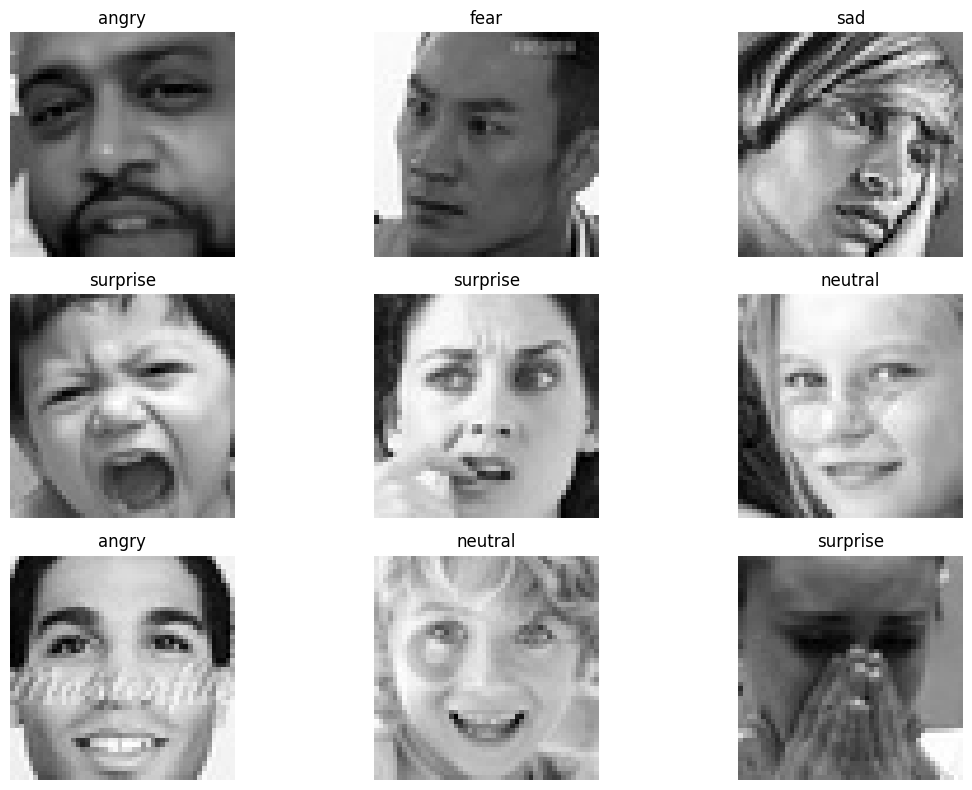

In [34]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(classes[np.argmax(labels[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()

5. Model 1: Baseline CNN

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [36]:
model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)
#to prevent overfitting

In [40]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.3049 - loss: 1.7194 - val_accuracy: 0.4031 - val_loss: 1.5443
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4199 - loss: 1.5053 - val_accuracy: 0.4579 - val_loss: 1.4150
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.4687 - loss: 1.3840 - val_accuracy: 0.5022 - val_loss: 1.3194
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5000 - loss: 1.3141 - val_accuracy: 0.5090 - val_loss: 1.2933
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5237 - loss: 1.2594 - val_accuracy: 0.5250 - val_loss: 1.2656
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5409 - loss: 1.2105 - val_accuracy: 0.5372 - val_loss: 1.2290
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5556 - loss: 1.1708 - val_accuracy: 0.5421 - val_loss: 1.2105
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5729 - loss: 1.1295 - 

In [42]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5506 - loss: 1.1869
Test Loss: 1.1869374513626099
Test Accuracy: 0.5505712032318115


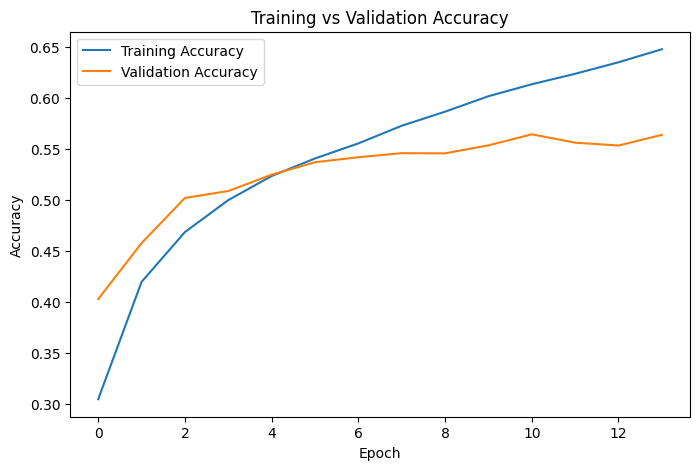

In [43]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

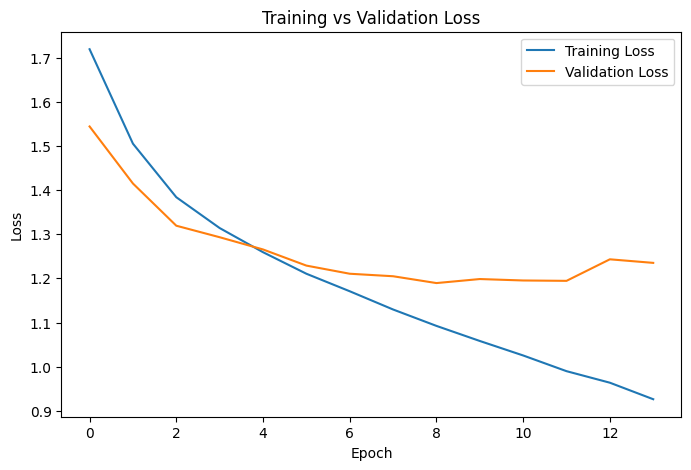

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [46]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


<Figure size 800x800 with 0 Axes>

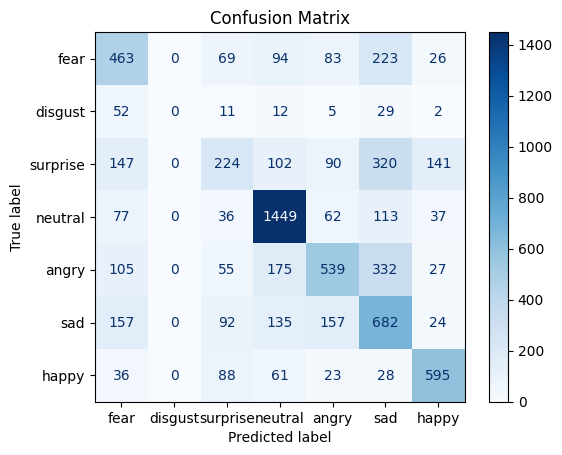

In [47]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [48]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

        fear       0.45      0.48      0.46       958
     disgust       0.00      0.00      0.00       111
    surprise       0.39      0.22      0.28      1024
     neutral       0.71      0.82      0.76      1774
       angry       0.56      0.44      0.49      1233
         sad       0.39      0.55      0.46      1247
       happy       0.70      0.72      0.71       831

    accuracy                           0.55      7178
   macro avg       0.46      0.46      0.45      7178
weighted avg       0.54      0.55      0.54      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step


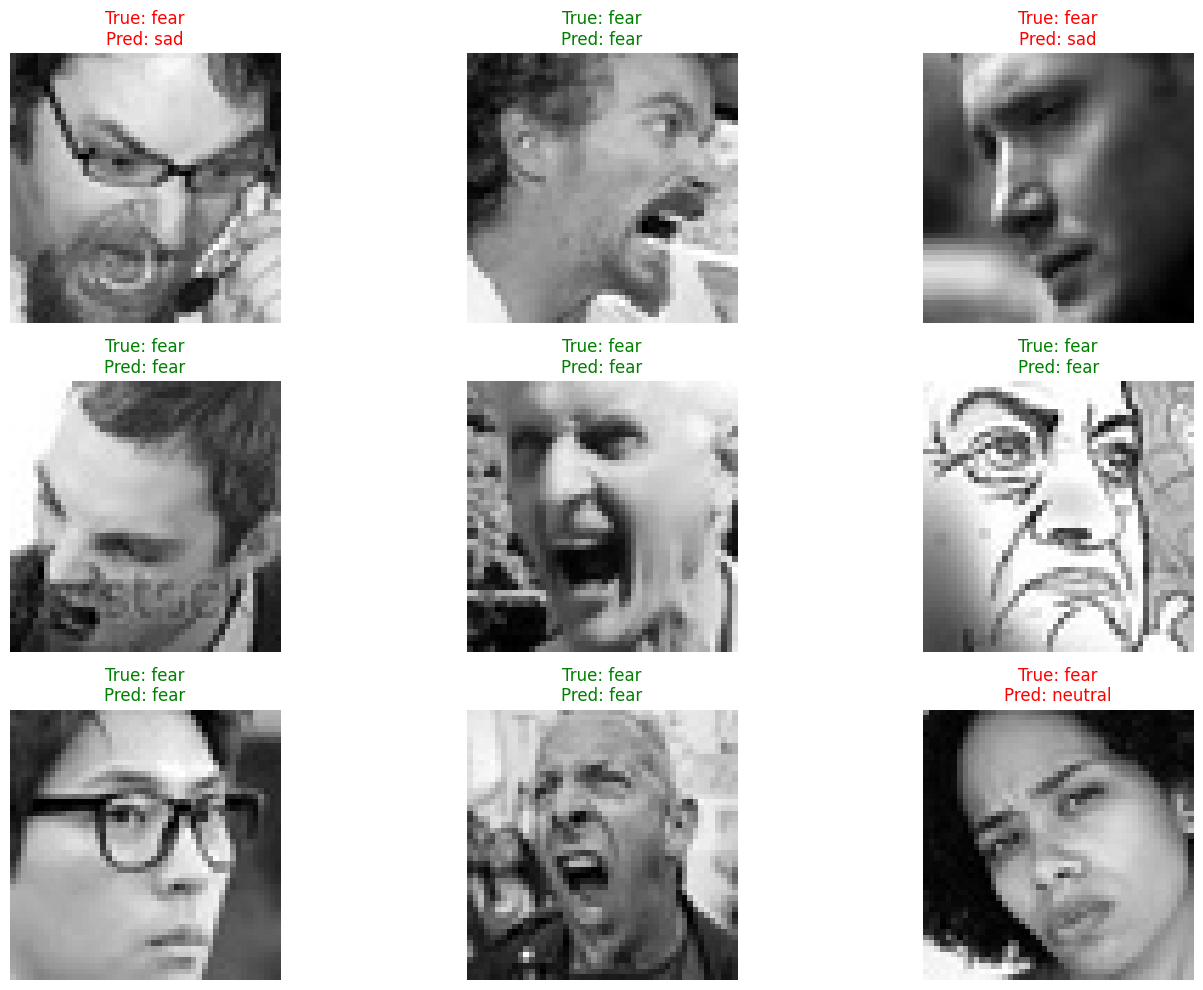

In [49]:
images, labels = next(test_generator)

predictions = model.predict(images)

plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    true_label = classes[np.argmax(labels[i])]
    predicted_label = classes[np.argmax(predictions[i])]

    color = "green" if true_label == predicted_label else "red"

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

6. Model 2: Improved CNN

In [55]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [56]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.regularizers import l2

model2 = Sequential()

# Block 1
model2.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(48,48,1)))
model2.add(BatchNormalization())

model2.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model2.add(BatchNormalization())

model2.add(MaxPooling2D((2,2)))
model2.add(Dropout(0.25))

# Block 2
model2.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(BatchNormalization())

model2.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model2.add(BatchNormalization())

model2.add(MaxPooling2D((2,2)))
model2.add(Dropout(0.30))

# Block 3
model2.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(BatchNormalization())

model2.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model2.add(BatchNormalization())

model2.add(MaxPooling2D((2,2)))
model2.add(Dropout(0.35))

# Classifier
model2.add(Flatten())

model2.add(Dense(512,
                 activation='relu',
                 kernel_regularizer=l2(0.0005)))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(7, activation='softmax'))

In [58]:
from tensorflow.keras.optimizers import Adam

model2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint2 = ModelCheckpoint(
    "best_model2.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [60]:
history2 = model2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[early_stopping2, checkpoint2]
)

Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 99ms/step - accuracy: 0.1937 - loss: 3.2907 - val_accuracy: 0.1777 - val_loss: 2.9246
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.2320 - loss: 2.8773 - val_accuracy: 0.2824 - val_loss: 2.3246
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.2563 - loss: 2.6661 - val_accuracy: 0.3261 - val_loss: 2.2274
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.2722 - loss: 2.5450 - val_accuracy: 0.3205 - val_loss: 2.2842
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.2897 - loss: 2.4462 - val_accuracy: 0.3564 - val_loss: 2.1593
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.3132 - loss: 2.3621 - val_accuracy: 0.3670 - val_loss: 2.0930
Epoch 7/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.3362 - loss: 2.2731 - val_accuracy: 0.3799 - val_loss: 2.0653
Epoch 8/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.3507 - loss: 2.1995 - 

In [61]:
test_loss2, test_accuracy2 = model2.evaluate(test_generator)

print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.6151 - loss: 1.1633
Test Loss: 1.163286805152893
Test Accuracy: 0.6150738596916199


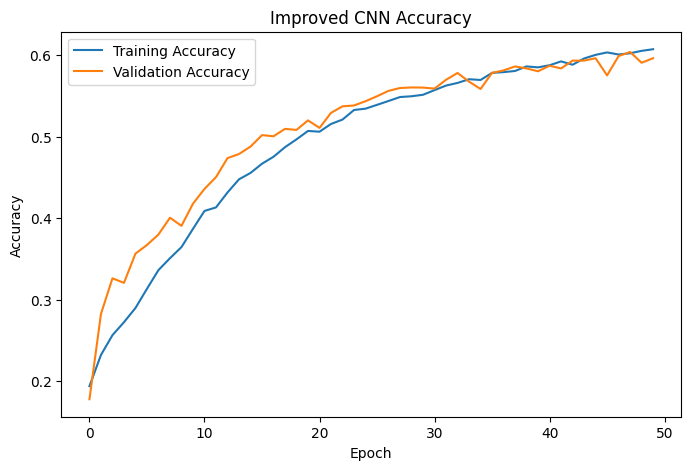

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN Accuracy")
plt.legend()

plt.show()

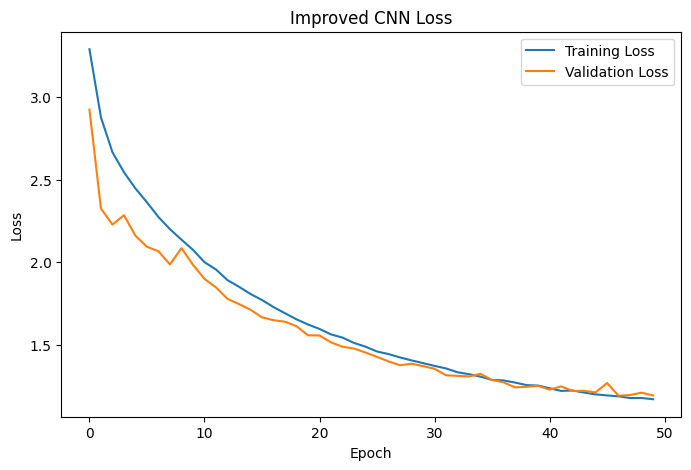

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN Loss")
plt.legend()

plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step


<Figure size 800x800 with 0 Axes>

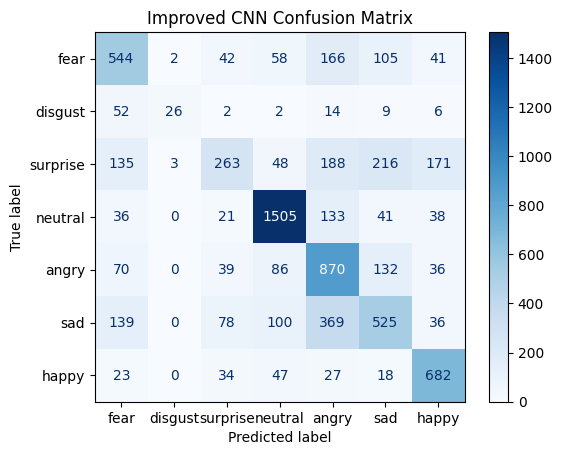

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions2 = model2.predict(test_generator)

y_pred2 = np.argmax(predictions2, axis=1)
y_true2 = test_generator.classes

cm = confusion_matrix(y_true2, y_pred2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.title("Improved CNN Confusion Matrix")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true2,
    y_pred2,
    target_names=classes
))

              precision    recall  f1-score   support

        fear       0.54      0.57      0.56       958
     disgust       0.84      0.23      0.37       111
    surprise       0.55      0.26      0.35      1024
     neutral       0.82      0.85      0.83      1774
       angry       0.49      0.71      0.58      1233
         sad       0.50      0.42      0.46      1247
       happy       0.68      0.82      0.74       831

    accuracy                           0.62      7178
   macro avg       0.63      0.55      0.55      7178
weighted avg       0.62      0.62      0.60      7178



In [66]:
model.save("baseline_cnn.keras")

In [67]:
model2.save("improved_cnn.keras")

MODEL COMPARISON


In [68]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Test Accuracy", "Test Loss"],
    "Baseline CNN": [test_accuracy, test_loss],
    "Improved CNN": [test_accuracy2, test_loss2]
})

comparison

,Metric,Baseline CNN,Improved CNN
0,Test Accuracy,0.550571,0.615074
1,Test Loss,1.186937,1.163287


In [70]:
model2.save("emotion_model.keras")
#saving the better model for deployment